<a href="https://colab.research.google.com/github/fzkmdly/Email_spam/blob/main/EmailSpam_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Library**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [ ]:
path = kagglehub.dataset_download("khashayarahmadi/email-spam")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'email-spam' dataset.
Path to dataset files: /kaggle/input/email-spam


In [ ]:
spam_df = pd.read_csv('/kaggle/input/email-spam/dataset.csv')

spam_df

,email,category
0,"URL: http://www.newsisfree.com/click/-1,817167...",not-spam
1,"On Thu, 19 Sep 2002, Bill Stoddard wrote:\n\n-...",not-spam
2,Dan Kohn <dan@dankohn.com> writes:\n\n\n\n> Gu...,not-spam
3,wintermute wrote:\n\n>>Anyone know where in Ir...,not-spam
4,"I attended the same conference, and was impres...",not-spam
...,...,...
3791,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",spam
3792,<html>\n\n<HEAD> \n\n<TITLE>creditfix</TITLE> ...,spam
3793,Hello:\n\n\n\nAre you satisfied with your ISP?...,spam
3794,<html><HEAD><TITLE>creditfix</TITLE> \n\n</HEA...,spam


In [ ]:
spam_df['category'].unique()

array(['not-spam', 'spam'], dtype=object)

In [ ]:
spam_df['category'].value_counts()

,count
category,
not-spam,1900
spam,1896


In [ ]:
spam_df.tail()

,email,category
3791,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",spam
3792,<html>\n\n<HEAD> \n\n<TITLE>creditfix</TITLE> ...,spam
3793,Hello:\n\n\n\nAre you satisfied with your ISP?...,spam
3794,<html><HEAD><TITLE>creditfix</TITLE> \n\n</HEA...,spam
3795,<HTML><HEAD></HEAD><BODY><b><FONT SIZE=3D4>In ...,spam


In [ ]:
spam_df.shape

(3796, 2)

In [ ]:
spam_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3796 entries, 0 to 3795
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   email     3796 non-null   object
 1   category  3796 non-null   object
dtypes: object(2)
memory usage: 59.4+ KB


In [ ]:
spam_df.describe()

,email,category
count,3796,3796
unique,3654,2
top,\n\nHello I am your hot lil horny toy.\n\n ...,not-spam
freq,7,1900


# **Data Cleaning**

In [ ]:
spam_df.isnull().sum()

,0
email,0
category,0


In [ ]:
spam_df.duplicated().sum()

np.int64(142)

In [ ]:
spam_df = spam_df.drop_duplicates()

spam_df.duplicated().sum()

np.int64(0)

In [ ]:
spam_df['category'].value_counts(normalize=True) * 100

,proportion
category,
not-spam,51.751505
spam,48.248495


In [ ]:
spam_df['category'].value_counts()

,count
category,
not-spam,1891
spam,1763


# **Explanatory Data Analysis**

In [ ]:
spam_df['email_length'] = spam_df['email'].apply(len)

/tmp/ipykernel_708/1719194188.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spam_df['email_length'] = spam_df['email'].apply(len)


In [ ]:
spam_df

,email,category,email_length
0,"URL: http://www.newsisfree.com/click/-1,817167...",not-spam,212
1,"On Thu, 19 Sep 2002, Bill Stoddard wrote:\n\n-...",not-spam,1597
2,Dan Kohn <dan@dankohn.com> writes:\n\n\n\n> Gu...,not-spam,2710
3,wintermute wrote:\n\n>>Anyone know where in Ir...,not-spam,851
4,"I attended the same conference, and was impres...",not-spam,2645
...,...,...,...
3790,"Attention Homeowners, \n\n\n\n""Now is the time...",spam,1049
3791,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",spam,2213
3793,Hello:\n\n\n\nAre you satisfied with your ISP?...,spam,804
3794,<html><HEAD><TITLE>creditfix</TITLE> \n\n</HEA...,spam,2918


In [ ]:
spam_df['email_length'].describe()

,email_length
count,3654.000000
mean,3413.334154
std,8300.199906
min,36.000000
25%,741.000000
50%,1391.500000
75%,3248.500000
max,234358.000000


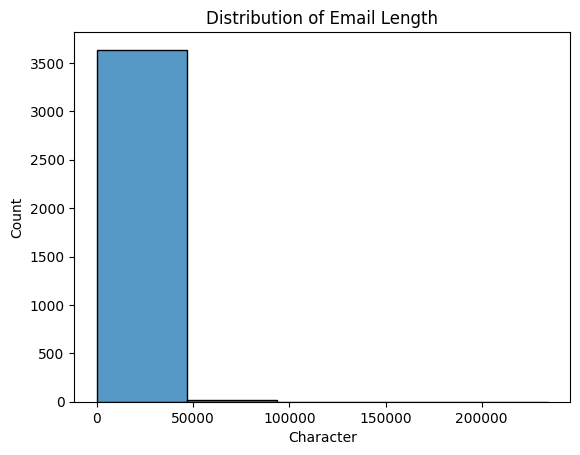

In [ ]:
sns.histplot(spam_df['email_length'], bins=5)
plt.xlabel('Character')
plt.title('Distribution of Email Length')
plt.show()

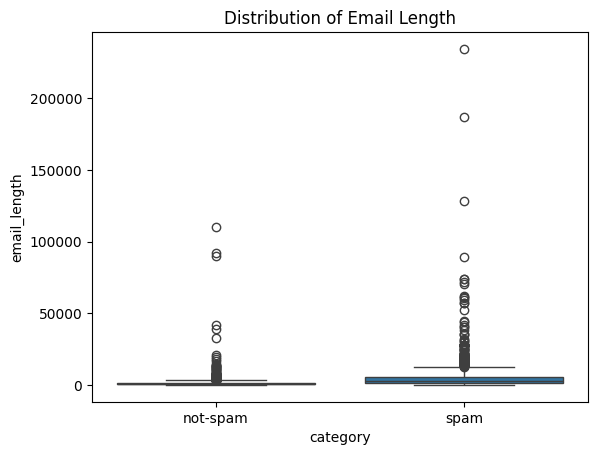

In [ ]:
sns.boxplot(spam_df, x='category', y='email_length')
plt.title('Distribution of Email Length')
plt.show()

In [ ]:
spam_df.groupby('category')['email_length'].mean()

,email_length
category,
not-spam,1632.056584
spam,5323.938741


In [ ]:
spam_df['word_count'] = spam_df['email'].apply(lambda x: len(x.split()))

/tmp/ipykernel_708/2990567267.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spam_df['word_count'] = spam_df['email'].apply(lambda x: len(x.split()))


In [ ]:
spam_df

,email,category,email_length,word_count
0,"URL: http://www.newsisfree.com/click/-1,817167...",not-spam,212,25
1,"On Thu, 19 Sep 2002, Bill Stoddard wrote:\n\n-...",not-spam,1597,271
2,Dan Kohn <dan@dankohn.com> writes:\n\n\n\n> Gu...,not-spam,2710,432
3,wintermute wrote:\n\n>>Anyone know where in Ir...,not-spam,851,141
4,"I attended the same conference, and was impres...",not-spam,2645,412
...,...,...,...,...
3790,"Attention Homeowners, \n\n\n\n""Now is the time...",spam,1049,146
3791,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",spam,2213,141
3793,Hello:\n\n\n\nAre you satisfied with your ISP?...,spam,804,123
3794,<html><HEAD><TITLE>creditfix</TITLE> \n\n</HEA...,spam,2918,222


In [ ]:
spam_df.groupby('category')['word_count'].mean()

,word_count
category,
not-spam,236.024855
spam,458.748157


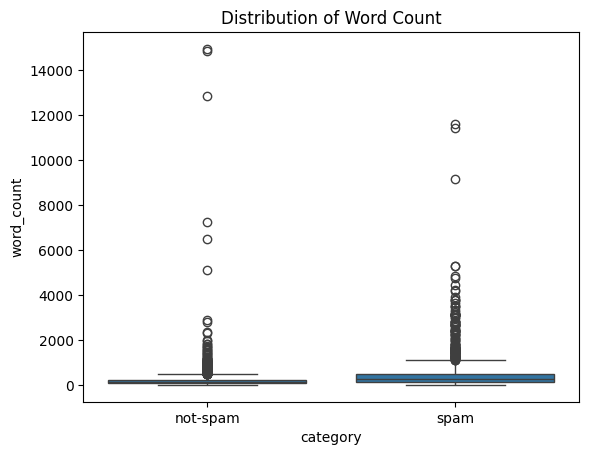

In [ ]:
sns.boxplot(spam_df, x='category', y='word_count')
plt.title('Distribution of Word Count')
plt.show()

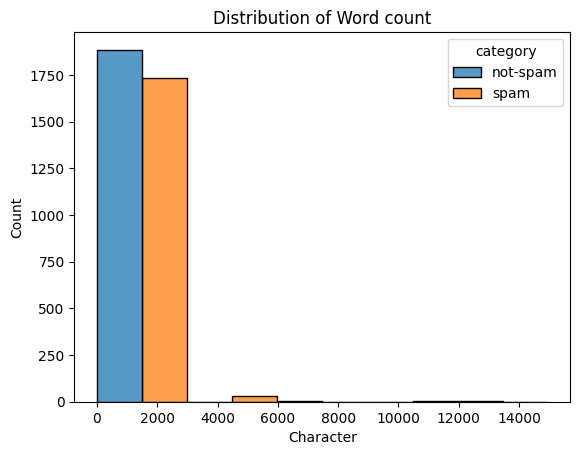

In [ ]:
sns.histplot(spam_df, x='word_count', hue='category', bins=5, multiple='dodge')
plt.xlabel('Character')
plt.title('Distribution of Word count')
plt.show()

In [ ]:
spam_df['word_count'].describe()

,word_count
count,3654.000000
mean,343.485495
std,708.329894
min,2.000000
25%,90.000000
50%,175.000000
75%,366.000000
max,14954.000000


In [ ]:
spam_df.nlargest(10, "word_count")

,email,category,email_length,word_count
1800,"\n\n""Free trade and free markets have proven t...",not-spam,89733,14954
1796,------------------------ Yahoo! Groups Sponsor...,not-spam,110372,14883
299,::: L I N K S F O R T H E D A Y :::\n\n\...,not-spam,91920,12840
2959,Reply From EnenKio\n\nThe following message wa...,spam,74148,11620
2102,\n\nSent e-mail message \n\n \n\nFrom: enen...,spam,71778,11456
3430,\n\n---259765881.993893904265.JavaMail.RovAdmi...,spam,70437,9166
648,"\n\n""60 Minutes II"" Bush Interview:\n\n\n\n(CB...",not-spam,41479,7242
302,I got to see Powell talk in March 2001 at the ...,not-spam,39147,6511
3190,\n\n--1074482631.993802752000.JavaMail.RovAdmi...,spam,40668,5296
3485,\n\n--646007810.993513231406.JavaMail.RovAdmin...,spam,62310,5293


In [ ]:
spam_df[spam_df['category'] == 'spam'].sample(10)

,email,category,email_length,word_count
1960,##############################################...,spam,3004,419
1952,"<!DOCTYPE HTML PUBLIC ""-//W3C//DTD HTML 4.0 Tr...",spam,653,53
3414,Greetings! \n\n\n\nYou are receiving this lett...,spam,2160,367
2797,"<html><body onload=""window.open('http://202.10...",spam,1924,144
2587,Do you want to make money from home? Are you ...,spam,774,106
3330,<html>\n\n<BODY BGCOLOR=3D#000000>\n\n<table w...,spam,1114,104
2387,"\n\nÐÏà¡±á Worldwide*\n\nGreat Restaurants, ...",spam,425,51
2832,This is a multi-part message in MIME format.\n...,spam,16961,1235
2965,\n\n<HTML><HEAD><TITLE>Untitled Document</TITL...,spam,3718,265
2128,This is a multi-part message in MIME format.\n...,spam,5862,90


In [ ]:
spam_df[spam_df['category'] == 'not-spam'].sample(10)

,email,category,email_length,word_count
30,I finally found the SpamAssassin ninja's! Aft...,not-spam,620,58
366,"First, thanks for all the rpms, and especially...",not-spam,719,97
45,"On Tue, 23 Jul 2002, Joseph S. Barrera III wro...",not-spam,386,66
418,"\n\n----- Original Message -----\n\nFrom: ""R. ...",not-spam,493,88
263,When I try to use apt-get upgrade\n\nit wants ...,not-spam,300,31
1110,Could anyone who is interested clarify this fo...,not-spam,1092,194
1053,"On Sun, 21 Jul 2002 05:11:08 -0400\n\nche <che...",not-spam,272,24
871,"I just set up razor and spamassassin, but I ke...",not-spam,1029,130
1791,"Yes, I know, dreadful subject. However, becaus...",not-spam,630,90
103,"On Tue, Aug 13, 2002 at 12:48:18AM +0100, wint...",not-spam,865,129


# Data Prep

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from scipy.sparse import hstack
from sklearn.preprocessing import LabelEncoder

In [ ]:
x = spam_df.drop(columns='category')
y = spam_df['category']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
tfidf = TfidfVectorizer(max_features=3000, stop_words='english')
X_train_text = tfidf.fit_transform(X_train['email'])
X_test_text = tfidf.transform(X_test['email'])

In [ ]:
scaler = RobustScaler()
X_train_num = scaler.fit_transform(X_train[['email_length', 'word_count']])
X_test_num = scaler.transform(X_test[['email_length', 'word_count']])

In [ ]:
X_train_final = hstack([X_train_text, X_train_num])
X_test_final = hstack([X_test_text, X_test_num])

In [ ]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.fit_transform(y_test)

# Modeling

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

## Logistic Regression

In [ ]:
LR_model = LogisticRegression(max_iter=1000)
LR_model.fit(X_train_final, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = LR_model.predict(X_test_final)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    not-spam       0.97      0.99      0.98       378
        spam       0.99      0.96      0.98       353

    accuracy                           0.98       731
   macro avg       0.98      0.98      0.98       731
weighted avg       0.98      0.98      0.98       731



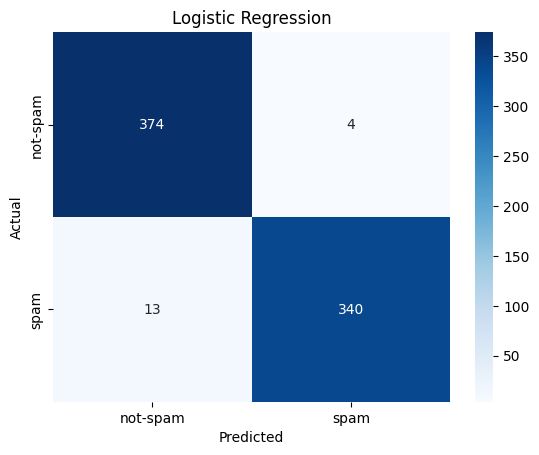

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not-spam', 'spam'],
            yticklabels=['not-spam', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression')
plt.show()

## Support Machine Vector

In [ ]:
SVM_model = LinearSVC(max_iter=5000)
SVM_model.fit(X_train_final, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(max_iter=5000)

In [ ]:
y_pred_Svm = SVM_model.predict(X_test_final)
print(classification_report(y_test, y_pred_Svm))

              precision    recall  f1-score   support

    not-spam       0.98      1.00      0.99       378
        spam       1.00      0.97      0.99       353

    accuracy                           0.99       731
   macro avg       0.99      0.99      0.99       731
weighted avg       0.99      0.99      0.99       731



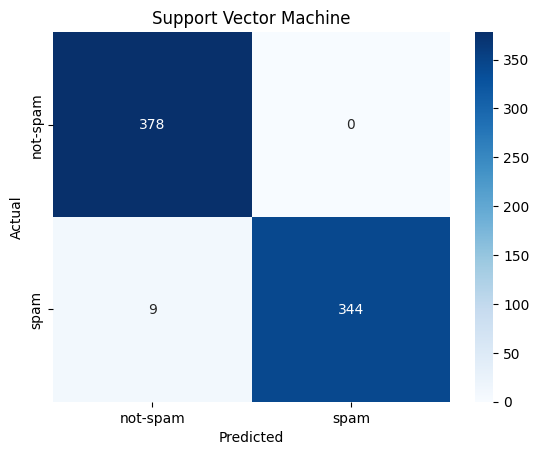

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_Svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not-spam', 'spam'],
            yticklabels=['not-spam', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Support Vector Machine')
plt.show()

## XGBoost

In [ ]:
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_final, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test_final)
print(classification_report(y_test_encoded, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       378
           1       0.99      0.97      0.98       353

    accuracy                           0.98       731
   macro avg       0.98      0.98      0.98       731
weighted avg       0.98      0.98      0.98       731



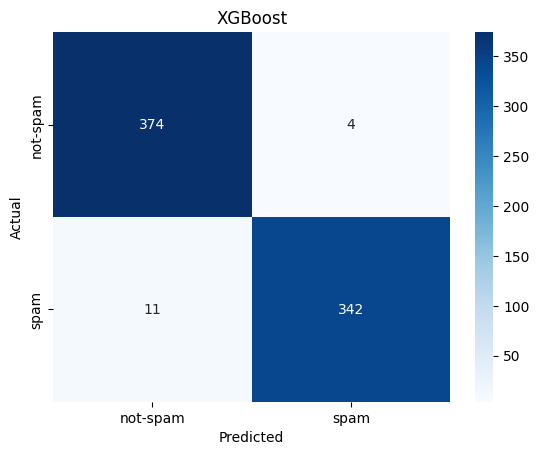

In [ ]:
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['not-spam', 'spam'],
            yticklabels=['not-spam', 'spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost')
plt.show()

# Cross Val

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [ ]:
# Encode label sekali di awal (dipakai semua model)
le = LabelEncoder()
y_encoded = le.fit_transform(spam_df['category'])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=3000, stop_words='english',
                                    sublinear_tf=True, max_df=0.9, min_df=2), 'email'),
        ('num', RobustScaler(), ['email_length', 'word_count'])
    ]
)

In [ ]:
models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(max_iter=1000))
    ]),
    'SVM (LinearSVC)': Pipeline([
        ('prep', preprocessor),
        ('clf', LinearSVC(max_iter=5000, dual=False))
    ]),
    'XGBoost': Pipeline([
        ('prep', preprocessor),
        ('clf', XGBClassifier(n_estimators=200, max_depth=6, random_state=42, eval_metric='logloss'))
    ])
}

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in models.items():
    scores = cross_val_score(pipeline, spam_df, y_encoded, cv=cv, scoring='f1_weighted')
    print(f"{name}:")
    print(f"  F1 per fold : {np.round(scores, 4)}")
    print(f"  Mean F1     : {scores.mean():.4f}")
    print(f"  Std Dev     : {scores.std():.4f}\n")

Logistic Regression:
  F1 per fold : [0.9863 0.9822 0.9767 0.9822 0.9863]
  Mean F1     : 0.9828
  Std Dev     : 0.0035

SVM (LinearSVC):
  F1 per fold : [0.9932 0.9822 0.9891 0.9877 0.9918]
  Mean F1     : 0.9888
  Std Dev     : 0.0038

XGBoost:
  F1 per fold : [0.9781 0.9808 0.9781 0.9767 0.9822]
  Mean F1     : 0.9792
  Std Dev     : 0.0020

